# Q1: Implementing an RNN for Text Generation

This program implements a character-level text generation model using an LSTM-based Recurrent Neural Network (RNN). The model is trained on a Shakespeare text dataset and learns to predict the next character in a sequence.

In [1]:
# Import required libraries
import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## Step 1: Load the Text Dataset

The Shakespeare dataset is loaded and used to train the character-level RNN model.

In [2]:
# Download Shakespeare text dataset
path_to_file = tf.keras.utils.get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)

# Read the text
text = open(path_to_file, "rb").read().decode("utf-8")

print("Length of text:", len(text))
print("\nSample text:\n")
print(text[:500])

Length of text: 1115394

Sample text:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## Step 2: Character Encoding

Each unique character is assigned an integer value. The text is converted into a sequence of integer IDs so that it can be processed by the neural network.

In [3]:
# Find all unique characters
vocab = sorted(set(text))

print("Number of unique characters:", len(vocab))
print("Characters:", vocab)

# Create mappings
char_to_idx = {char: idx for idx, char in enumerate(vocab)}
idx_to_char = np.array(vocab)

# Convert entire text into integer IDs
text_as_int = np.array([char_to_idx[c] for c in text])

print("\nFirst 100 encoded characters:")
print(text_as_int[:100])

Number of unique characters: 65
Characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

First 100 encoded characters:
[18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56 43  1 61 43
  1 54 56 53 41 43 43 42  1 39 52 63  1 44 59 56 58 46 43 56  6  1 46 43
 39 56  1 51 43  1 57 54 43 39 49  8  0  0 13 50 50 10  0 31 54 43 39 49
  6  1 57 54 43 39 49  8  0  0 18 47 56 57 58  1 15 47 58 47 64 43 52 10
  0 37 53 59]


## Step 3: Prepare Training Sequences

The encoded text is divided into fixed-length sequences. Each input sequence is paired with the next character as its target so the LSTM can learn to predict the next character.

In [4]:
# Define sequence length
seq_length = 100

# Create input sequences and target sequences
inputs = []
targets = []

# Use a portion of the dataset for faster training
training_text = text_as_int[:200000]

for i in range(0, len(training_text) - seq_length, seq_length):
    inputs.append(training_text[i:i + seq_length])
    targets.append(training_text[i + 1:i + seq_length + 1])

# Convert lists to NumPy arrays
X = np.array(inputs)
y = np.array(targets)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (1999, 100)
Target shape: (1999, 100)


## Step 4: Build the LSTM RNN Model

The model uses an Embedding layer to represent characters, an LSTM layer to learn sequential patterns in the text, and a Dense output layer to predict the next character.

In [5]:
# Number of unique characters
vocab_size = len(vocab)

# Build the LSTM model
model = Sequential([
    Embedding(vocab_size, 64),
    LSTM(128, return_sequences=True),
    Dense(vocab_size)
])

# Build the model for input sequences of length 100
model.build(input_shape=(None, seq_length))

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100, 65)        │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,361 (435.00 KB)

 Trainable params: 111,361 (435.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Train the LSTM Model

The model is compiled using the Adam optimizer and Sparse Categorical Cross-Entropy loss. During training, the LSTM learns character patterns from the Shakespeare dataset so that it can predict the next character in a sequence.

In [6]:
# Define the loss function
loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

# Compile the model
model.compile(
    optimizer="adam",
    loss=loss
)

# Train the model
history = model.fit(
    X,
    y,
    epochs=5,
    batch_size=64
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - loss: 3.5712
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - loss: 3.1408
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - loss: 2.7991
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - loss: 2.5641
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - loss: 2.4504


## Step 6: Generate New Text

The trained LSTM model generates new text one character at a time. Starting with an initial string, the model predicts the probability of the next character, samples one character, and repeats the process to create a new sequence of text.

In [7]:
def generate_text(model, start_string, num_generate=500, temperature=1.0):

    # Convert the starting string into integer IDs
    input_ids = [char_to_idx[c] for c in start_string]

    generated_text = start_string

    # Generate one character at a time
    for _ in range(num_generate):

        # Keep the latest characters
        current_input = input_ids[-seq_length:]

        # Pad the sequence if it is shorter than seq_length
        if len(current_input) < seq_length:
            current_input = [0] * (seq_length - len(current_input)) + current_input

        # Convert input into a NumPy array
        input_tensor = np.array([current_input])

        # Predict the next character
        predictions = model(input_tensor, training=False)

        # Use prediction from the last time step
        predictions = predictions[:, -1, :]

        # Apply temperature scaling
        predictions = predictions / temperature

        # Sample the next character
        predicted_id = tf.random.categorical(
            predictions,
            num_samples=1
        )[0, 0].numpy()

        # Convert predicted ID back into a character
        predicted_char = idx_to_char[predicted_id]

        # Add predicted character to generated text
        generated_text += predicted_char
        input_ids.append(predicted_id)

    return generated_text

generated_text = generate_text(
    model,
    start_string="ROMEO: ",
    num_generate=100,
    temperature=0.8
)

print("Generated Text:")
print(generated_text)

In [8]:
print("Low Temperature (0.5):")
print(generate_text(model, "ROMEO: ", 30, temperature=0.5))

print("\nMedium Temperature (1.0):")
print(generate_text(model, "ROMEO: ", 30, temperature=1.0))

print("\nHigh Temperature (1.5):")
print(generate_text(model, "ROMEO: ", 30, temperature=1.5))

Low Temperature (0.5):
ROMEO: ERENUIUS:
Ae se an and mat dou

Medium Temperature (1.0):
ROMEO: SEULNSirracem. mnow,d dotradg.

High Temperature (1.5):
ROMEO: EOR:rri em lwabbs hot ront
H
u


## Temperature Scaling Explanation

Temperature scaling controls the randomness of the text generated by the LSTM model.

A **low temperature (0.5)** makes the model favor characters with higher predicted probabilities. This produces more predictable and less random text.

A **medium temperature (1.0)** provides a balance between predictable and random character selection.

A **high temperature (1.5)** increases randomness by giving lower-probability characters a greater chance of being selected. This can produce more diverse text, but it may also make the generated text less coherent.

From the experiment, increasing the temperature increased the randomness of the generated text. Therefore, temperature scaling controls the trade-off between predictable and diverse text generation.

# Q2: Sentiment Classification Using RNN

This section implements an LSTM-based RNN for sentiment classification using the IMDB movie review dataset. The model classifies reviews as positive or negative.

In [9]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import confusion_matrix, classification_report

print("Q2 libraries imported successfully!")

Q2 libraries imported successfully!


## Step 1: Load the IMDB Sentiment Dataset

The IMDB dataset contains movie reviews labeled as positive or negative. The dataset is loaded using TensorFlow/Keras and will be used to train and evaluate the LSTM sentiment classifier.

In [11]:
# Set vocabulary size
vocab_size = 10000

# Load the IMDB movie review dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nFirst training review (encoded):")
print(X_train[0][:50])

print("\nLabel of first review:", y_train[0])

if y_train[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

Training samples: 25000
Testing samples: 25000

First training review (encoded):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447]

Label of first review: 1
Sentiment: Positive


## Step 2: Preprocess and Pad the Sequences

The IMDB reviews are already tokenized and represented as sequences of integer word IDs. Since the reviews have different lengths, padding is applied so that every review has the same length of 200 words.

In [12]:
# Set maximum review length
max_length = 200

# Pad training and testing sequences
X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nFirst padded review:")
print(X_train[0])

Training data shape: (25000, 200)
Testing data shape: (25000, 200)

First padded review:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4  226   22   2

## Step 3: Build the LSTM Sentiment Classification Model

The model uses an Embedding layer to represent words as dense vectors, an LSTM layer to learn patterns in the review text, and a Dense output layer with a sigmoid activation function to classify each review as positive or negative.

In [13]:
# Build the LSTM sentiment classification model
sentiment_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

# Build model with input length of 200
sentiment_model.build(input_shape=(None, max_length))

# Display model architecture
sentiment_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Train the LSTM Model

The LSTM model is compiled using the Adam optimizer and binary cross-entropy loss because sentiment classification is a binary classification problem. The model is trained using the IMDB training reviews to learn how to classify positive and negative sentiments.

In [14]:
# Compile the sentiment classification model
sentiment_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train the model
history = sentiment_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 166ms/step - accuracy: 0.5225 - loss: 0.6927 - val_accuracy: 0.5474 - val_loss: 0.6871
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step - accuracy: 0.6030 - loss: 0.6580 - val_accuracy: 0.5346 - val_loss: 0.6898
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.5915 - loss: 0.6533 - val_accuracy: 0.5664 - val_loss: 0.6954


## Step 5: Evaluate the Sentiment Classification Model

The trained LSTM model is evaluated using the test dataset. Predictions are converted into positive or negative classes and evaluated using a confusion matrix and classification report.

In [15]:
# Evaluate the model on test data
test_loss, test_accuracy = sentiment_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.5534 - loss: 0.7060

Test Loss: 0.7060202956199646
Test Accuracy: 0.5533999800682068


In [16]:
# Predict sentiment probabilities
y_pred_prob = sentiment_model.predict(
    X_test,
    batch_size=256,
    verbose=1
)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob.flatten() >= 0.5).astype(int)

print("First 20 actual labels:")
print(y_test[:20])

print("\nFirst 20 predicted labels:")
print(y_pred[:20])

98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step
First 20 actual labels:
[0 1 1 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0]

First 20 predicted labels:
[0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0]


## Confusion Matrix

The confusion matrix shows how many positive and negative reviews were classified correctly and incorrectly by the LSTM model.

Confusion Matrix:
[[12171   329]
 [10836  1664]]


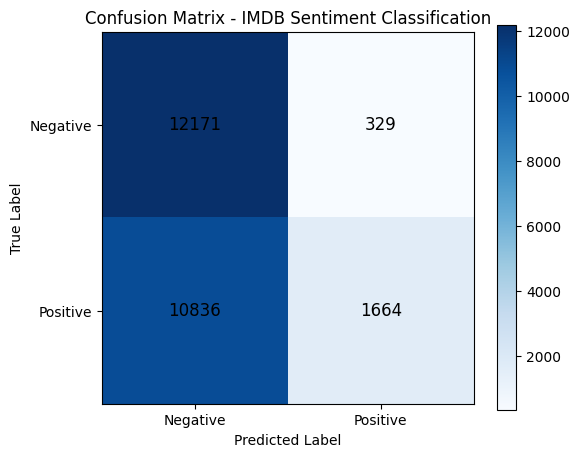

In [17]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - IMDB Sentiment Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

# Add values inside matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 fontsize=12)

plt.colorbar()
plt.show()

In [18]:
# Generate classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.97      0.69     12500
    Positive       0.83      0.13      0.23     12500

    accuracy                           0.55     25000
   macro avg       0.68      0.55      0.46     25000
weighted avg       0.68      0.55      0.46     25000



## Precision–Recall Tradeoff

Precision and recall are important metrics for evaluating a sentiment classification model.

**Precision** measures how many reviews predicted as a particular sentiment are actually correct. High precision means the model produces fewer false positive predictions.

**Recall** measures how many of the actual reviews belonging to a sentiment class are correctly identified by the model. High recall means the model misses fewer relevant reviews.

There is often a tradeoff between precision and recall. Increasing the classification threshold may improve precision but reduce recall, while decreasing the threshold may improve recall but reduce precision.

In sentiment classification, this tradeoff is important because the desired balance depends on the application. Therefore, precision, recall, and F1-score provide more information about model performance than accuracy alone.

# Q3: Convolution Operations with Different Parameters

This section demonstrates convolution on a 5×5 input matrix using a 3×3 kernel. Different stride and padding settings are used to observe how these parameters affect the output feature maps.

## Step 1: Define the Input Matrix and Kernel

A 5×5 input matrix and a 3×3 convolution kernel are defined according to the assignment. The kernel is used to extract local changes in the input matrix.

In [19]:
# Import required libraries
import numpy as np
import tensorflow as tf

# Define the 5x5 input matrix
input_matrix = np.array([
    [1,  2,  3,  4,  5],
    [6,  7,  8,  9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
], dtype=np.float32)

# Define the 3x3 kernel
kernel = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float32)

print("Input Matrix:")
print(input_matrix)

print("\n3x3 Kernel:")
print(kernel)

Input Matrix:
[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15.]
 [16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25.]]

3x3 Kernel:
[[ 0.  1.  0.]
 [ 1. -4.  1.]
 [ 0.  1.  0.]]


## Step 2: Prepare Data for Convolution

TensorFlow convolution expects four-dimensional input and filter tensors. Therefore, the input matrix and kernel are reshaped before applying the convolution operations.

In [20]:
# Reshape input to: [batch, height, width, channels]
input_tensor = input_matrix.reshape(1, 5, 5, 1)

# Reshape kernel to:
# [kernel_height, kernel_width, input_channels, output_channels]
kernel_tensor = kernel.reshape(3, 3, 1, 1)

print("Input tensor shape:", input_tensor.shape)
print("Kernel tensor shape:", kernel_tensor.shape)

Input tensor shape: (1, 5, 5, 1)
Kernel tensor shape: (3, 3, 1, 1)


## Step 3: Convolution with Different Strides and Padding

Four convolution operations are performed using different combinations of stride and padding:

1. Stride = 1, Padding = VALID
2. Stride = 1, Padding = SAME
3. Stride = 2, Padding = VALID
4. Stride = 2, Padding = SAME

In [21]:
# 1. Stride = 1, Padding = VALID
output_1 = tf.nn.conv2d(
    input_tensor,
    kernel_tensor,
    strides=[1, 1, 1, 1],
    padding="VALID"
)

# 2. Stride = 1, Padding = SAME
output_2 = tf.nn.conv2d(
    input_tensor,
    kernel_tensor,
    strides=[1, 1, 1, 1],
    padding="SAME"
)

# 3. Stride = 2, Padding = VALID
output_3 = tf.nn.conv2d(
    input_tensor,
    kernel_tensor,
    strides=[1, 2, 2, 1],
    padding="VALID"
)

# 4. Stride = 2, Padding = SAME
output_4 = tf.nn.conv2d(
    input_tensor,
    kernel_tensor,
    strides=[1, 2, 2, 1],
    padding="SAME"
)

print("Convolution operations completed successfully!")

Convolution operations completed successfully!


In [22]:
print("Stride = 1, Padding = VALID")
print(output_1.numpy().squeeze())

print("\nStride = 1, Padding = SAME")
print(output_2.numpy().squeeze())

print("\nStride = 2, Padding = VALID")
print(output_3.numpy().squeeze())

print("\nStride = 2, Padding = SAME")
print(output_4.numpy().squeeze())

Stride = 1, Padding = VALID
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Stride = 1, Padding = SAME
[[  4.   3.   2.   1.  -6.]
 [ -5.   0.   0.   0. -11.]
 [-10.   0.   0.   0. -16.]
 [-15.   0.   0.   0. -21.]
 [-46. -27. -28. -29. -56.]]

Stride = 2, Padding = VALID
[[0. 0.]
 [0. 0.]]

Stride = 2, Padding = SAME
[[  4.   2.  -6.]
 [-10.   0. -16.]
 [-46. -28. -56.]]


# Q4: CNN Feature Extraction with Filters and Pooling

## Task 1: Edge Detection Using Sobel Filters

This task applies Sobel filters to a grayscale image to detect edges in the x-direction and y-direction. The original image, Sobel-X result, and Sobel-Y result are displayed for comparison.

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV Version:", cv2.__version__)
print("Libraries imported successfully!")

OpenCV Version: 5.0.0
Libraries imported successfully!


In [24]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV Version:", cv2.__version__)

OpenCV Version: 5.0.0


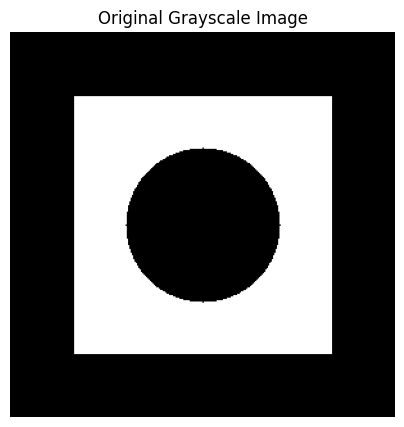

In [26]:
# Create a simple grayscale sample image
image = np.zeros((300, 300), dtype=np.uint8)

# Draw a white rectangle
cv2.rectangle(image, (50, 50), (250, 250), 255, -1)

# Draw a black circle inside the rectangle
cv2.circle(image, (150, 150), 60, 0, -1)

# Display the sample image
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

### Apply Sobel X and Sobel Y Filters

The Sobel-X filter detects changes primarily in the horizontal (x) direction, while the Sobel-Y filter detects changes primarily in the vertical (y) direction. The filters are applied to the grayscale image using convolution.

In [27]:
# Define Sobel-X filter
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Define Sobel-Y filter
sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

# Apply Sobel filters
edge_x = cv2.filter2D(image, cv2.CV_64F, sobel_x)
edge_y = cv2.filter2D(image, cv2.CV_64F, sobel_y)

# Convert results to absolute values for display
edge_x_display = cv2.convertScaleAbs(edge_x)
edge_y_display = cv2.convertScaleAbs(edge_y)

print("Sobel filters applied successfully!")

Sobel filters applied successfully!


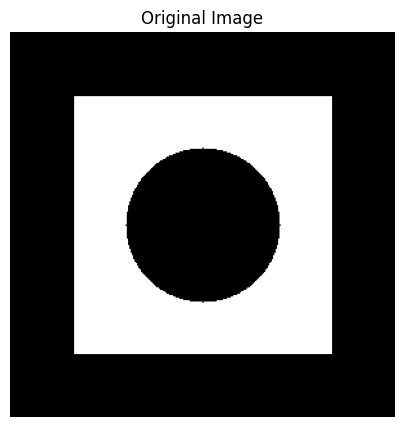

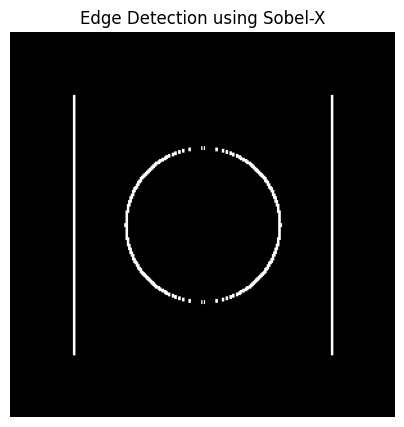

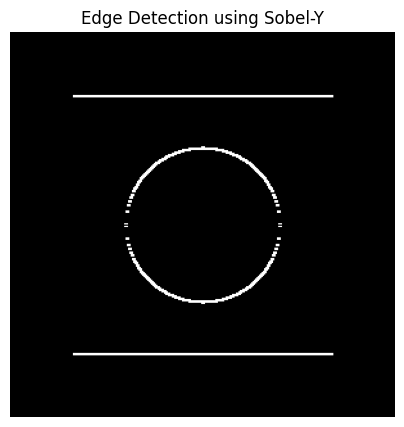

In [28]:
# Display original image
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# Display Sobel-X result
plt.figure(figsize=(5, 5))
plt.imshow(edge_x_display, cmap="gray")
plt.title("Edge Detection using Sobel-X")
plt.axis("off")
plt.show()

# Display Sobel-Y result
plt.figure(figsize=(5, 5))
plt.imshow(edge_y_display, cmap="gray")
plt.title("Edge Detection using Sobel-Y")
plt.axis("off")
plt.show()

## Task 2: Max Pooling and Average Pooling

A random 4×4 matrix is created to represent an input image. A 2×2 Max Pooling operation and a 2×2 Average Pooling operation are applied to demonstrate how pooling reduces the spatial dimensions of the input.

In [29]:
# Set seed so the random matrix is reproducible
np.random.seed(42)

# Create a random 4x4 matrix
random_matrix = np.random.randint(
    1, 10, size=(4, 4)
).astype(np.float32)

print("Original 4x4 Matrix:")
print(random_matrix)

Original 4x4 Matrix:
[[7. 4. 8. 5.]
 [7. 3. 7. 8.]
 [5. 4. 8. 8.]
 [3. 6. 5. 2.]]


In [30]:
# Reshape matrix for TensorFlow
pool_input = random_matrix.reshape(1, 4, 4, 1)

# Apply 2x2 Max Pooling
max_pool = tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=2
)

max_pooled = max_pool(pool_input)

# Apply 2x2 Average Pooling
avg_pool = tf.keras.layers.AveragePooling2D(
    pool_size=(2, 2),
    strides=2
)

average_pooled = avg_pool(pool_input)

# Print results
print("Original Matrix:")
print(random_matrix)

print("\nMax Pooled Matrix:")
print(max_pooled.numpy().squeeze())

print("\nAverage Pooled Matrix:")
print(average_pooled.numpy().squeeze())

Original Matrix:
[[7. 4. 8. 5.]
 [7. 3. 7. 8.]
 [5. 4. 8. 8.]
 [3. 6. 5. 2.]]

Max Pooled Matrix:
[[7. 8.]
 [6. 8.]]

Average Pooled Matrix:
[[5.25 7.  ]
 [4.5  5.75]]


# Q5: Implementing and Comparing CNN Architectures

## Task 1: Implement AlexNet Architecture

This task implements a simplified AlexNet architecture using TensorFlow/Keras. The network contains convolutional layers for feature extraction, max-pooling layers for dimensionality reduction, fully connected layers for classification, dropout layers to reduce overfitting, and a Softmax output layer for 10 classes.

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

print("AlexNet libraries imported successfully!")

AlexNet libraries imported successfully!


In [32]:
# Build simplified AlexNet model
alexnet_model = Sequential([
    
    Input(shape=(227, 227, 3)),
    
    # First Convolution Layer
    Conv2D(
        96,
        kernel_size=(11, 11),
        strides=4,
        activation="relu"
    ),
    
    # First Max Pooling Layer
    MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    ),
    
    # Second Convolution Layer
    Conv2D(
        256,
        kernel_size=(5, 5),
        padding="same",
        activation="relu"
    ),
    
    # Second Max Pooling Layer
    MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    ),
    
    # Third Convolution Layer
    Conv2D(
        384,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    
    # Fourth Convolution Layer
    Conv2D(
        384,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    
    # Fifth Convolution Layer
    Conv2D(
        256,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),
    
    # Third Max Pooling Layer
    MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    ),
    
    # Flatten
    Flatten(),
    
    # Fully Connected Layer
    Dense(4096, activation="relu"),
    
    # 50% Dropout
    Dropout(0.5),
    
    # Fully Connected Layer
    Dense(4096, activation="relu"),
    
    # 50% Dropout
    Dropout(0.5),
    
    # Output Layer
    Dense(10, activation="softmax")
])

print("AlexNet model created successfully!")

AlexNet model created successfully!


In [33]:
print("AlexNet Model Summary:")
alexnet_model.summary()

AlexNet Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,322,314 (222.48 MB)

 Trainable params: 58,322,314 (222.48 MB)

 Non-trainable params: 0 (0.00 B)

## Task 2: Implement a Residual Block and ResNet

This task implements a simple ResNet-like architecture. Residual blocks use skip connections that add the original input to the output of convolutional layers. These connections help information flow through deeper neural networks.

In [34]:
from tensorflow.keras.layers import Input, Conv2D, Add, Activation, Flatten, Dense
from tensorflow.keras.models import Model

print("ResNet libraries imported successfully!")

ResNet libraries imported successfully!


In [35]:
def residual_block(input_tensor, filters=64):
    
    # First convolution layer
    x = Conv2D(
        filters,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )(input_tensor)
    
    # Second convolution layer
    x = Conv2D(
        filters,
        kernel_size=(3, 3),
        padding="same"
    )(x)
    
    # Skip connection
    x = Add()([input_tensor, x])
    
    # Activation after addition
    x = Activation("relu")(x)
    
    return x

print("Residual block function created successfully!")

Residual block function created successfully!


In [36]:
# Define input
inputs = Input(shape=(64, 64, 3))

# Initial convolution layer
x = Conv2D(
    64,
    kernel_size=(7, 7),
    strides=2,
    padding="same",
    activation="relu"
)(inputs)

# First residual block
x = residual_block(x, 64)

# Second residual block
x = residual_block(x, 64)

# Flatten layer
x = Flatten()(x)

# Fully connected layer
x = Dense(128, activation="relu")(x)

# Output layer
outputs = Dense(10, activation="softmax")(x)

# Create model
resnet_model = Model(
    inputs=inputs,
    outputs=outputs,
    name="Simple_ResNet"
)

print("ResNet-like model created successfully!")

ResNet-like model created successfully!


In [37]:
print("ResNet-like Model Summary:")
resnet_model.summary()

ResNet-like Model Summary:


Model: "Simple_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      9,472 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d_5[0][0],   │
│                     │ 64)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ activation[0][0], │
│                     │ 64)               │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 65536)     │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │  8,388,736 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10)        │      1,290 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,547,210 (32.61 MB)

 Trainable params: 8,547,210 (32.61 MB)

 Non-trainable params: 0 (0.00 B)